Load data, scaler and model

In [1]:
import pandas as pd
import joblib
import sys
sys.path.append("..")

df = pd.read_pickle("../data/features.pkl")
scaler = joblib.load("../models/scaler_v1.pkl")
model = joblib.load("../models/model_v1.pkl")

Prepare the data

In [2]:
from python_editor.data_processing import split_by_developer

train, test = split_by_developer(df, test_size=0.3, random_state=0)

In [3]:
num_features = [
                "characters",
                "code_compactness",
                "chars_per_line",
                "comment_ratio",
                "variable_ratio",
                "avg_var_name",
                "num_funcs_and_classes",
                "avg_func_class_name",
                "avg_func_class_chars",
                "avg_func_class_args",
                "func_class_docstring_ratio"
            ]

test_transformed = test.copy()
test_transformed.loc[:, num_features] = scaler.transform(test_transformed[num_features])

In [4]:
from python_editor.feature_generation import get_vectorized_features_and_label

features = [
                "characters",
                "code_compactness",
                "chars_per_line",
                "comment_ratio",
                "has_docstring",
                "variable_ratio",
                "avg_var_name",
                "num_funcs_and_classes",
                "avg_func_class_name",
                "avg_func_class_chars",
                "avg_func_class_args",
                "func_class_docstring_ratio"
            ]

X_test, y_test = get_vectorized_features_and_label(test_transformed, features)

Get predictions

In [5]:
y_pred = model.predict(X_test)

Residual analysis shows us:

1- Downward slope which means the model is overestimating at higher values

2- Asymmetry in residuals (more negatives than positives) which means the model overestimates in general. This is due to many files having zero-score. we will try log transformation to improve it

3- Heteroscedasticity predictions around 5 is wide-spreaded and around higher values is narrow which means model is less certain in higher values

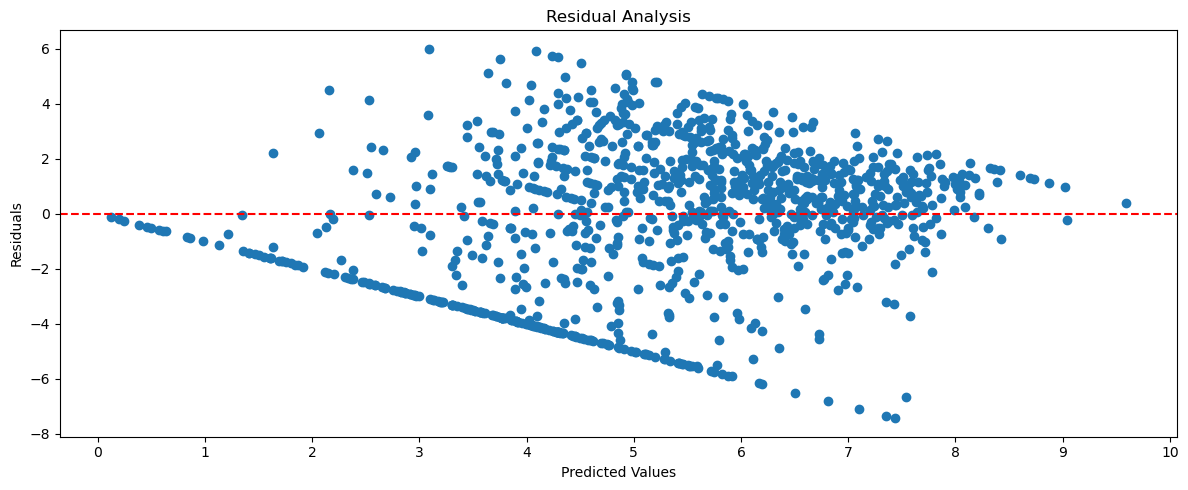

In [6]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

plt.scatter(y_pred, y_test-y_pred)
plt.axhline(y=0, color="r", linestyle="--")
plt.xticks(range(11))
plt.title("Residual Analysis")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [7]:
test.loc[:, "error"] = y_test - y_pred

/tmp/ipykernel_5102/4180407341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, "error"] = y_test - y_pred


We examine top performing, most over estimated and most under estimated examples

In [8]:
from python_editor.model_evaluation import get_top_k


top_performing, most_over_estimated, most_under_estimated = get_top_k(test, "error", 3)

to_display = [
    "pylint_score",
    "characters",
    "code_compactness",
    "chars_per_line",
    "comment_ratio",
    "has_docstring",
    "variable_ratio",
    "avg_var_name",
    "num_funcs_and_classes",
    "avg_func_class_name",
    "avg_func_class_chars",
    "avg_func_class_args",
    "func_class_docstring_ratio",
    "error"
]

From top performing examples we notice:

1- They have score near the middle

2- They have average number of characters

3- They have no docstring

4- They have functions/classes

In [9]:
top_performing[to_display]

,pylint_score,characters,code_compactness,chars_per_line,comment_ratio,has_docstring,variable_ratio,avg_var_name,num_funcs_and_classes,avg_func_class_name,avg_func_class_chars,avg_func_class_args,func_class_docstring_ratio,error
3019,5.625000,1419.0,0.866667,31.533333,0.038760,0.0,0.000000,0.000000,4.0,13.50,659.75,1.25,0.50,0.000523
700,6.470588,2918.0,0.756303,24.521008,0.071282,1.0,0.004798,7.928571,4.0,6.75,872.00,1.25,0.75,0.002548
2321,4.444444,363.0,1.000000,36.300000,0.195592,0.0,0.000000,0.000000,0.0,0.00,0.00,0.00,0.00,-0.004539


Overestimated examples have average number of characters and have functions/classes

In [10]:
most_over_estimated[to_display]

,pylint_score,characters,code_compactness,chars_per_line,comment_ratio,has_docstring,variable_ratio,avg_var_name,num_funcs_and_classes,avg_func_class_name,avg_func_class_chars,avg_func_class_args,func_class_docstring_ratio,error
3341,0.0,2435.0,0.753425,33.356164,0.105544,1.0,0.002464,11.333333,2.0,8.500000,2127.000000,2.000000,0.500000,-7.433057
932,0.0,2134.0,0.657143,30.485714,0.009841,1.0,0.004217,9.222222,3.0,10.333333,885.000000,2.000000,0.333333,-7.355157
1370,0.0,4415.0,0.840336,37.100840,0.130464,0.0,0.001359,11.500000,9.0,10.555556,972.555556,2.111111,0.555556,-7.104301


Underestimated examples have very low or very high number of characters and the most underestimated one has no functions/classes

In [11]:
most_under_estimated[to_display]

,pylint_score,characters,code_compactness,chars_per_line,comment_ratio,has_docstring,variable_ratio,avg_var_name,num_funcs_and_classes,avg_func_class_name,avg_func_class_chars,avg_func_class_args,func_class_docstring_ratio,error
3366,9.100529,62236.0,0.889974,40.518229,0.057378,0.0,0.001334,13.746988,6.0,11.666667,10094.166667,0.5,0.0,6.006954
2470,10.000000,212.0,0.714286,15.142857,0.108491,1.0,0.018868,10.250000,0.0,0.000000,0.000000,0.0,0.0,5.911623
1649,10.000000,1185.0,0.944444,21.944444,0.008439,1.0,0.000844,4.000000,0.0,0.000000,0.000000,0.0,0.0,5.761953


Feature importance shows that the model relies on embeddings and generated features

In [12]:
from python_editor.model_evaluation import get_feature_importance


embedding_dim = test["embedding"][0].shape[0]

importance_df = get_feature_importance(model, embedding_dim, features)
importance_df.head(10)

,feature,importance
449,449,0.056640
137,137,0.019368
66,66,0.016122
773,variable_ratio,0.015037
318,318,0.012088
561,561,0.010978
672,672,0.009959
779,func_class_docstring_ratio,0.009587
244,244,0.009185
772,has_docstring,0.008160


In [13]:
train_transformed = train.copy()
train_transformed.loc[:, num_features] = scaler.transform(train_transformed[num_features])
X_train, y_train = get_vectorized_features_and_label(train_transformed, features)

Shapley values confirms that both embeddings and generated features are relevant. Here are a [video](https://youtu.be/NBg7YirBTN8?si=se9qccwpeFOoNLoF) that explains shapley values intutively and a [playlist](https://www.youtube.com/playlist?list=PLcrc6i6xwaQSw8553tgt1p8XOMFEdQCbl) that explains the maths behind it

 99%|===================| 1052/1060 [00:59<00:00]        

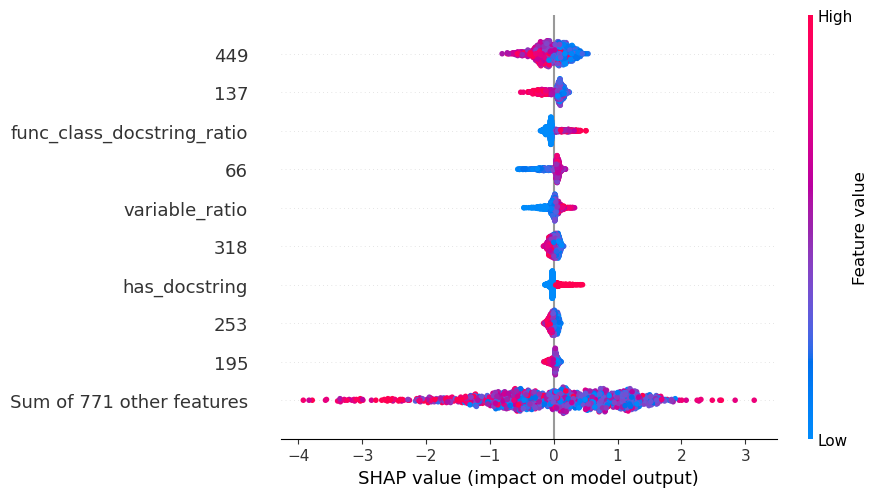

In [14]:
import shap
from python_editor.model_evaluation import get_shap_df
shap.initjs()

shap_values = get_shap_df(model, embedding_dim, features, X_train, X_test)
shap.plots.beeswarm(shap_values)